In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "D:\\VNSGU_PDA_DATA\\Data-Analytics-using-Python-Minor-Project\\Data\\processed\\cleaned_student_data.xlsx"
df = pd.read_excel(file_path)


# Display basic info
print(df.head())
print(df.info())

   Seat Number                        Name  \
0         1001  ADEP SAIKRISHNA KISHORBHAI   
1         1002      AHIR KRISH PRAMODKUMAR   
2         1003       AHIR MEET MANSUKHBHAI   
3         1004    AHIR MITKUMAR SURESHBHAI   
4         1005       AHIR NILAY ARVINDBHAI   

                                     College Name  Total Marks  SGPA Result  \
0  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          332  6.18   PASS   
1  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          347  6.36   PASS   
2  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          348  6.18   PASS   
3  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          347  6.36   PASS   
4  V.S. PATEL COLLEGE OF ARTS & SCIENCE, BILIMORA          325  5.82   PASS   

                                   Course_Name  AWD_Ext_Th  AWD_Ext_Pr  \
0  CERTIFICATE COURSE ON GOOGLE PRODUCTS(CCGP)          11          22   
1  CERTIFICATE COURSE ON GOOGLE PRODUCTS(CCGP)           9          19   
2  CERTIFICATE COURSE ON G

In [31]:

df['Total Marks'] = df['Total Marks'].str.split('/').str[0]

# Convert to numeric
df['Total Marks'] = pd.to_numeric(df['Total Marks'], errors='coerce')

# Drop missing if any
df = df.dropna(subset=['Total Marks'])

AttributeError: Can only use .str accessor with string values!

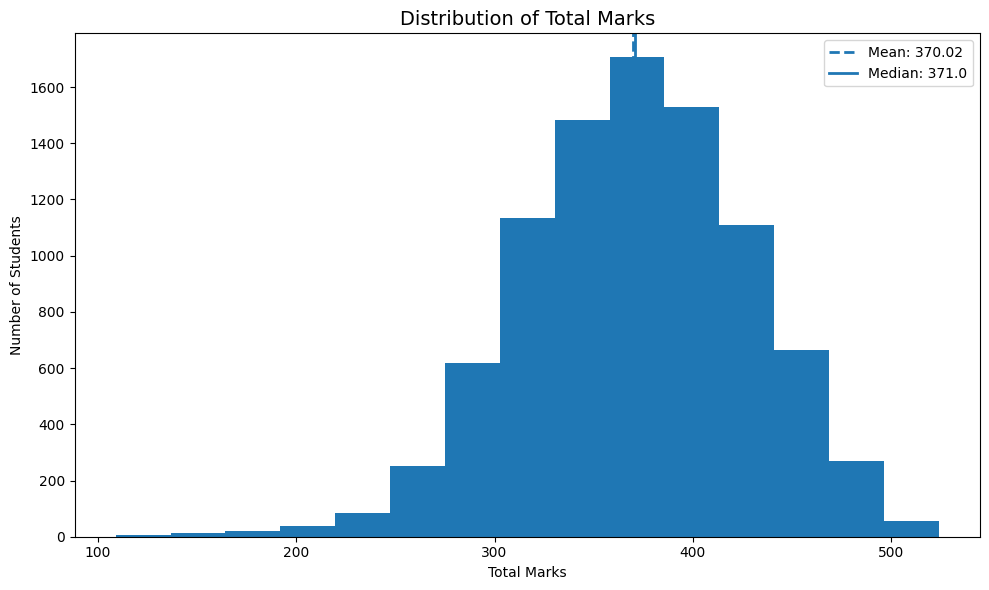

In [37]:
plt.figure(figsize=(10,6))

plt.hist(df['Total Marks'], bins=15)

mean_marks = df['Total Marks'].mean()
median_marks = df['Total Marks'].median()

plt.axvline(mean_marks, linestyle='dashed', linewidth=2, label=f'Mean: {round(mean_marks,2)}')
plt.axvline(median_marks, linestyle='solid', linewidth=2, label=f'Median: {round(median_marks,2)}')

plt.title("Distribution of Total Marks", fontsize=14)
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.legend()

plt.tight_layout()
plt.show()

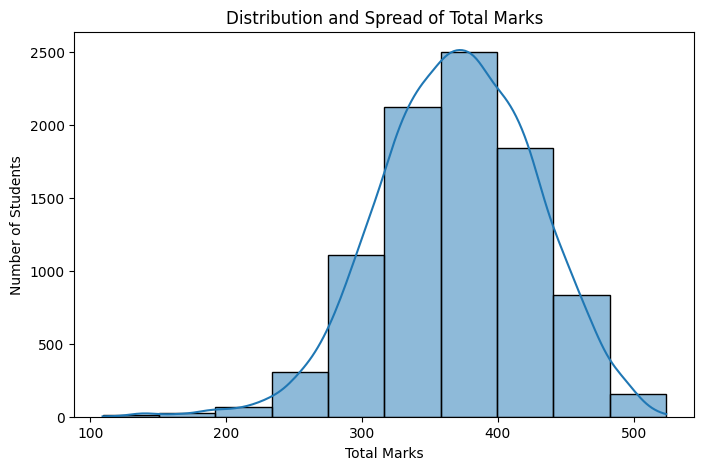

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Marks'], bins=10, kde=True)
plt.title("Distribution and Spread of Total Marks")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.show()

In [39]:
df.columns.to_list()

['Seat Number',
 'Name',
 'College Name',
 'Total Marks',
 'SGPA',
 'Result',
 'Course_Name',
 'AWD_Ext_Th',
 'AWD_Ext_Pr',
 'AWD_Ext_Total',
 'AWD_Int_Th',
 'AWD_Int_Pr',
 'AWD_Int_Total',
 'AWD_Total',
 'WFS_Ext_Th',
 'WFS_Ext_Pr',
 'WFS_Ext_Total',
 'WFS_Int_Th',
 'WFS_Int_Pr',
 'WFS_Int_Total',
 'WFS_Total',
 '.NET_Ext_Th',
 '.NET_Ext_Pr',
 '.NET_Ext_Total',
 '.NET_Int_Th',
 '.NET_Int_Pr',
 '.NET_Int_Total',
 '.NET_Total',
 'LOS_Ext_Th',
 'LOS_Ext_Pr',
 'LOS_Ext_Total',
 'LOS_Int_Th',
 'LOS_Int_Pr',
 'LOS_Int_Total',
 'LOS_Total',
 'NT_Ext_Total',
 'NT_Int_Total',
 'NT_Total',
 'CC_Ext_Total',
 'CC_Int_Total',
 'CC_Total',
 'Percentage']

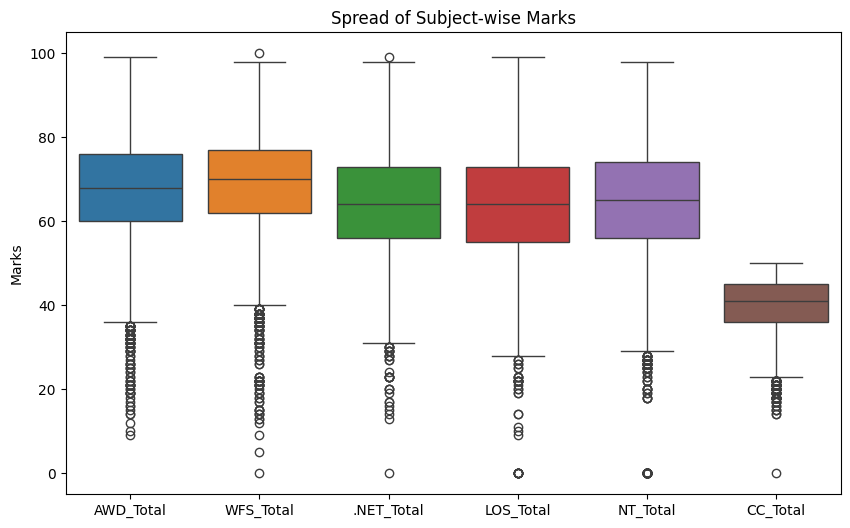

In [40]:
# plt.figure(figsize=(10,6))
# sns.boxplot(data=df[['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']])
# plt.title("Spread of Subject-wise Marks")
# plt.ylabel("Marks")
# plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df[['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']])
plt.title("Spread of Subject-wise Marks")
plt.ylabel("Marks")
plt.show()

### Uni Variate


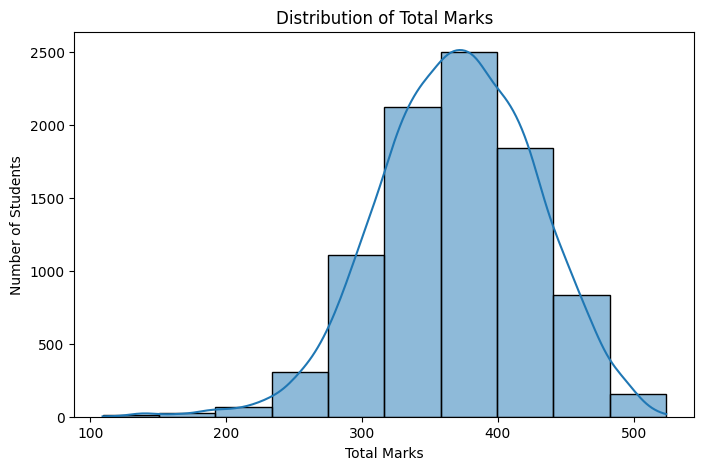

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Marks'], bins=10, kde=True)
plt.title("Distribution of Total Marks")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.show()

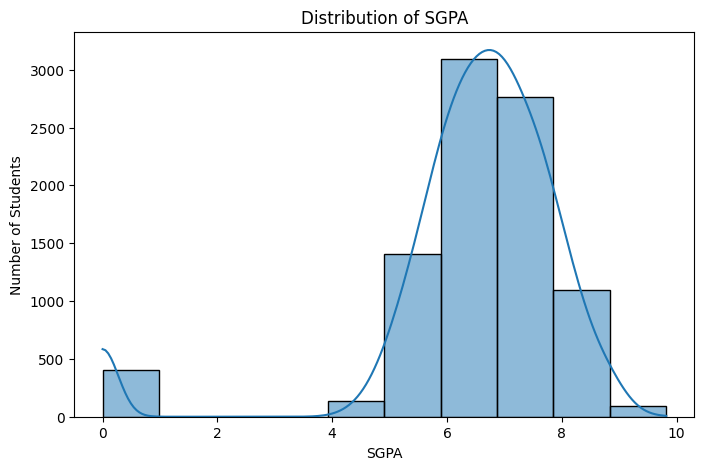

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['SGPA'], bins=10, kde=True)
plt.title("Distribution of SGPA")
plt.xlabel("SGPA")
plt.ylabel("Number of Students")
plt.show()

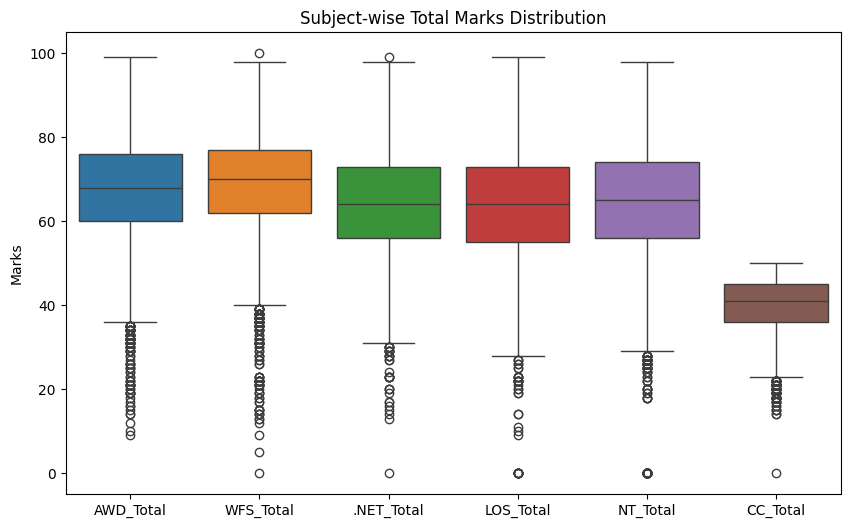

In [5]:
subject_totals = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']

plt.figure(figsize=(10,6))
sns.boxplot(data=df[subject_totals])
plt.title("Subject-wise Total Marks Distribution")
plt.ylabel("Marks")
plt.show()

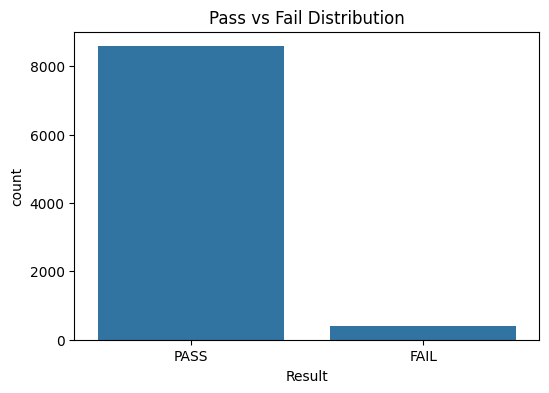

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Result', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

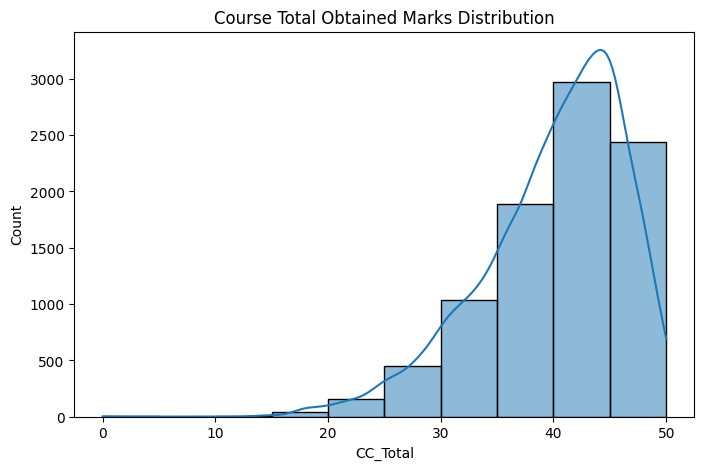

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['CC_Total'], bins=10, kde=True)
plt.title("Course Total Obtained Marks Distribution")
plt.show()

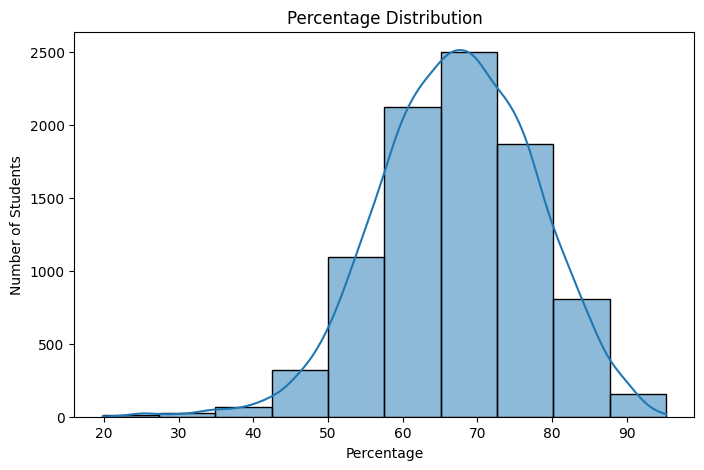

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Percentage'], bins=10, kde=True)
plt.title("Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.show()

{'AWD': 66, 'WFS': 65, 'NET': 40, 'LOS': 63, 'NT': 147, 'CC': 12}


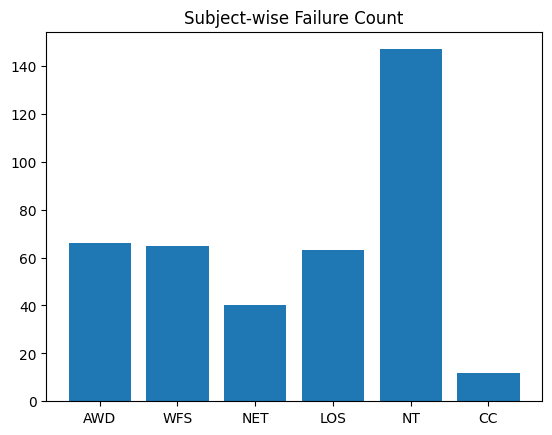

In [14]:
failure_counts = {
    'AWD': (df['AWD_Total'] < 33).sum(),
    'WFS': (df['WFS_Total'] < 33).sum(),
    'NET': (df['.NET_Total'] < 33).sum(),
    'LOS': (df['LOS_Total'] < 33).sum(),
    'NT': (df['NT_Total'] < 33).sum(),
    'CC': (df['CC_Total'] < 18).sum(),
}

print(failure_counts)

plt.bar(failure_counts.keys(), failure_counts.values())
plt.title("Subject-wise Failure Count")
plt.show()

Subject-wise Failure Count:
AWD: 66
WFS: 65
NET: 40
LOS: 63
NT: 147
CC: 12


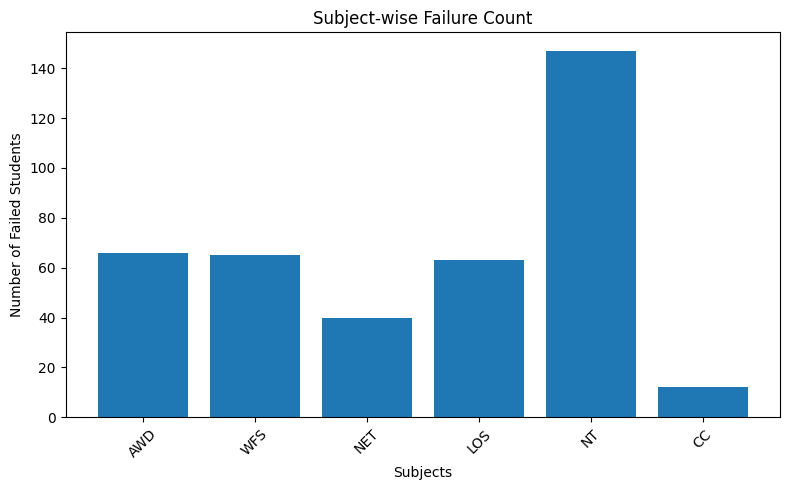

In [15]:
import matplotlib.pyplot as plt

# Subject-wise Failure Count based on Passing Criteria
failure_counts = {
    'AWD': (df['AWD_Total'] < 33).sum(),
    'WFS': (df['WFS_Total'] < 33).sum(),
    'NET': (df['.NET_Total'] < 33).sum(),
    'LOS': (df['LOS_Total'] < 33).sum(),
    'NT': (df['NT_Total'] < 33).sum(),
    'CC': (df['CC_Total'] < 18).sum(),
}

# Print Failure Counts
print("Subject-wise Failure Count:")
for subject, count in failure_counts.items():
    print(f"{subject}: {count}")

# Plot Bar Graph
plt.figure(figsize=(8,5))
plt.bar(failure_counts.keys(), failure_counts.values())
plt.title("Subject-wise Failure Count")
plt.xlabel("Subjects")
plt.ylabel("Number of Failed Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bivariate


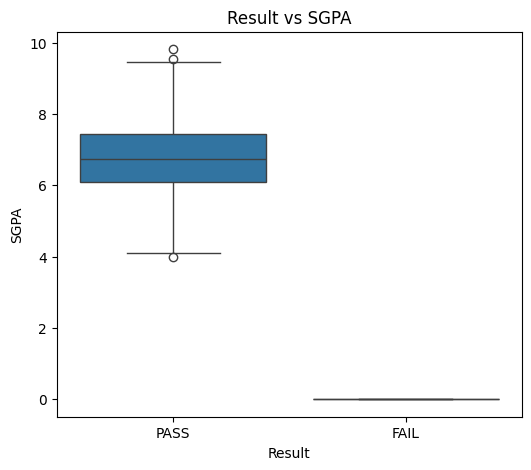

In [20]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Result', y='SGPA', data=df)
plt.title("Result vs SGPA")
plt.show()

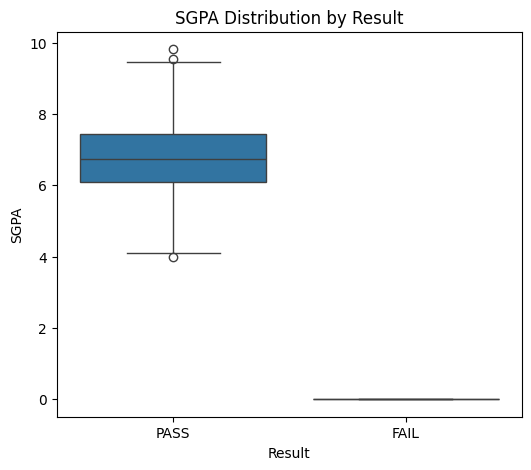

In [22]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Result', y='SGPA', data=df)
plt.title("SGPA Distribution by Result")
plt.show()

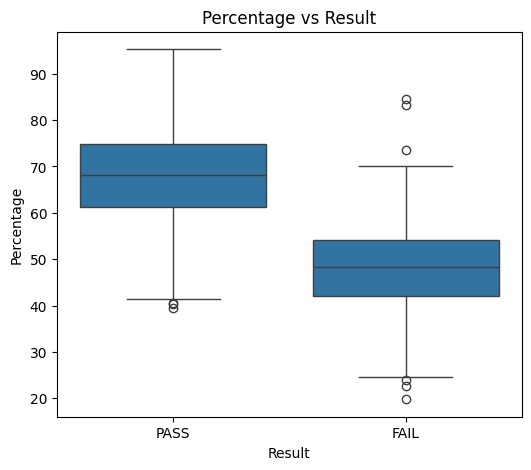

In [23]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Result', y='Percentage', data=df)
plt.title("Percentage vs Result")
plt.show()

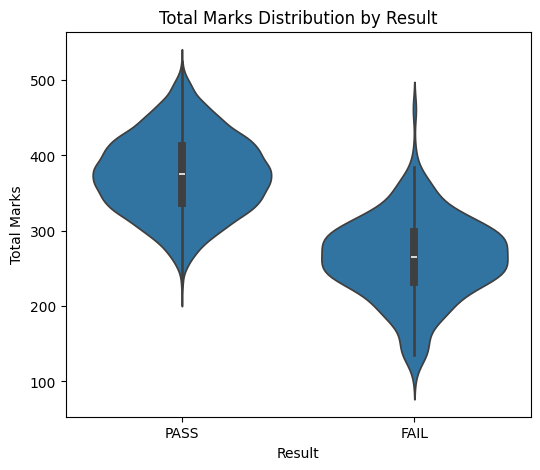

In [29]:
plt.figure(figsize=(6,5))
sns.violinplot(x='Result', y='Total Marks', data=df)
plt.title("Total Marks Distribution by Result")
plt.show()

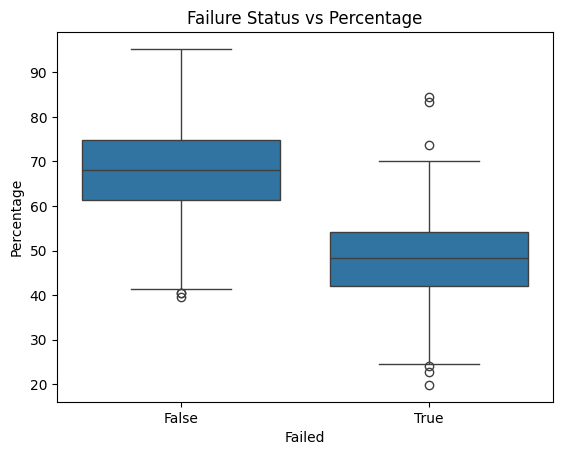

In [28]:
df['Failed'] = df['Result'] != 'PASS'

sns.boxplot(x='Failed', y='Percentage', data=df)
plt.title("Failure Status vs Percentage")
plt.show()

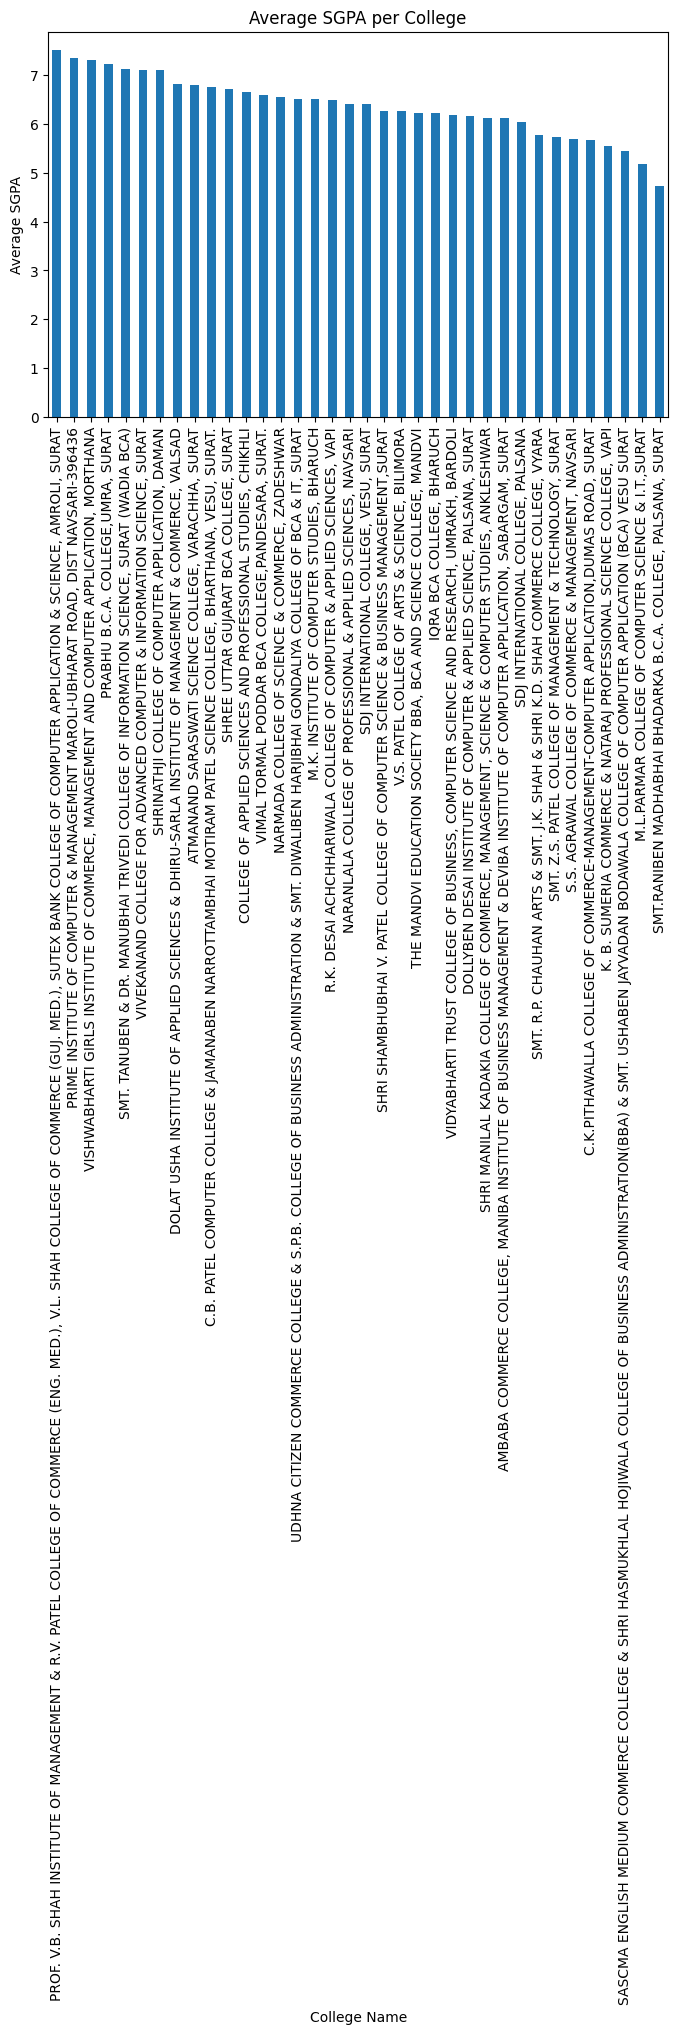

In [31]:
college_sgpa = df.groupby('College Name')['SGPA'].mean().sort_values(ascending=False)

college_sgpa.plot(kind='bar', figsize=(8,5))
plt.title("Average SGPA per College")
plt.ylabel("Average SGPA")
plt.show()

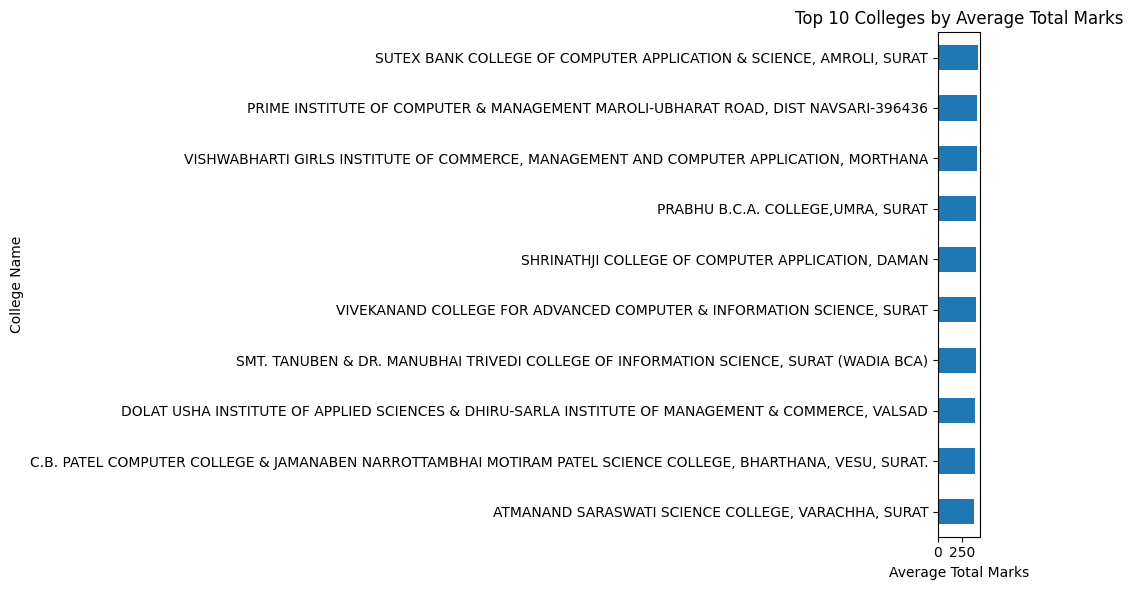

In [8]:
college_avg_total = df.groupby('College Name')['Total Marks'].mean().sort_values(ascending=False)

top10 = college_avg_total.head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Colleges by Average Total Marks")
plt.xlabel("Average Total Marks")
plt.tight_layout()
plt.show()

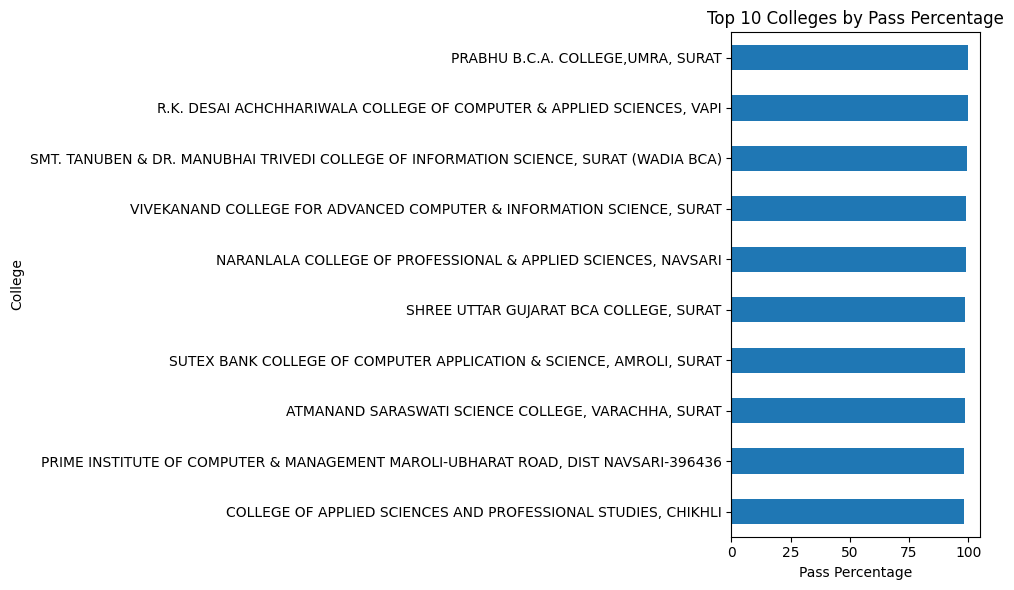

In [6]:
pass_percentage = df.groupby('College Name')['Result'].apply(
    lambda x: (x == 'PASS').mean() * 100
).sort_values(ascending=False)

top10 = pass_percentage.head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Colleges by Pass Percentage")
plt.xlabel("Pass Percentage")
plt.ylabel("College")
plt.tight_layout()
plt.show()

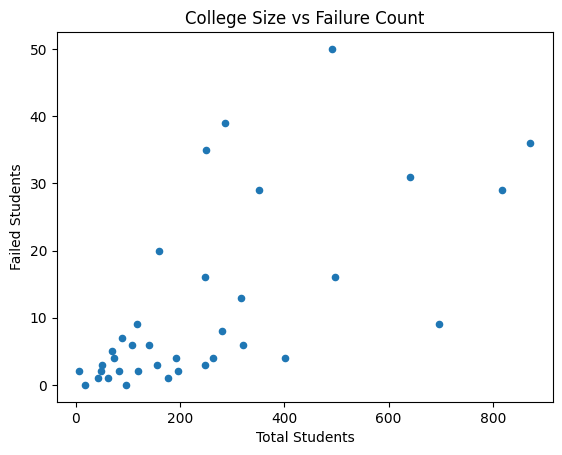

In [9]:
college_size = df.groupby('College Name').size()
college_failures = df[df['Result']!='PASS'].groupby('College Name').size()

comparison = pd.DataFrame({
    'Total Students': college_size,
    'Failed Students': college_failures
}).fillna(0)

comparison.plot(kind='scatter', x='Total Students', y='Failed Students')
plt.title("College Size vs Failure Count")
plt.show()

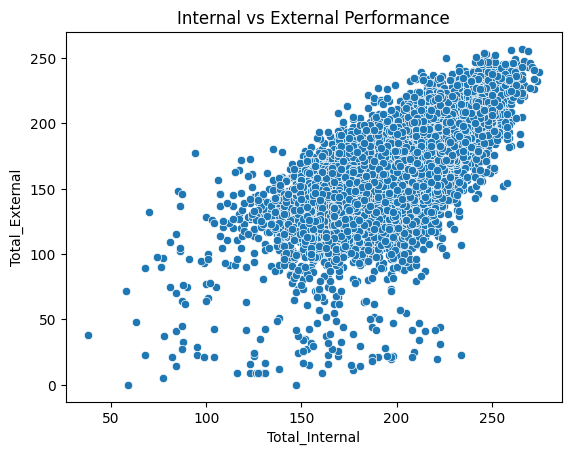

In [10]:
df['Total_Internal'] = df[['AWD_Int_Total','WFS_Int_Total','.NET_Int_Total',
                           'LOS_Int_Total','NT_Int_Total','CC_Int_Total']].sum(axis=1)

df['Total_External'] = df[['AWD_Ext_Total','WFS_Ext_Total','.NET_Ext_Total',
                           'LOS_Ext_Total','NT_Ext_Total','CC_Ext_Total']].sum(axis=1)

sns.scatterplot(x=df['Total_Internal'], y=df['Total_External'])
plt.title("Internal vs External Performance")
plt.show()

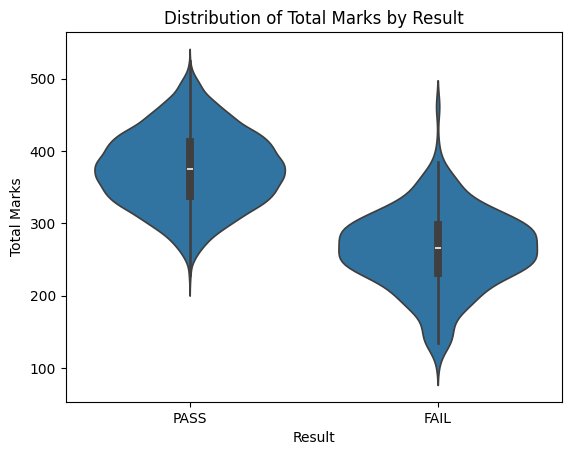

In [11]:
sns.violinplot(x='Result', y='Total Marks', data=df)
plt.title("Distribution of Total Marks by Result")
plt.show()

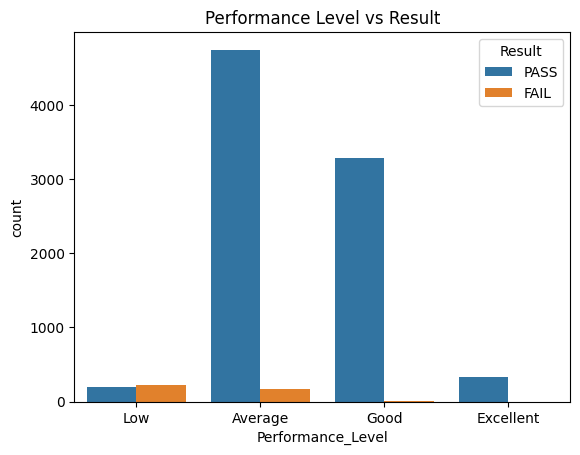

In [12]:
df['Performance_Level'] = pd.cut(df['Percentage'],
                                  bins=[0,50,70,85,100],
                                  labels=['Low','Average','Good','Excellent'])

sns.countplot(x='Performance_Level', hue='Result', data=df)
plt.title("Performance Level vs Result")
plt.show()

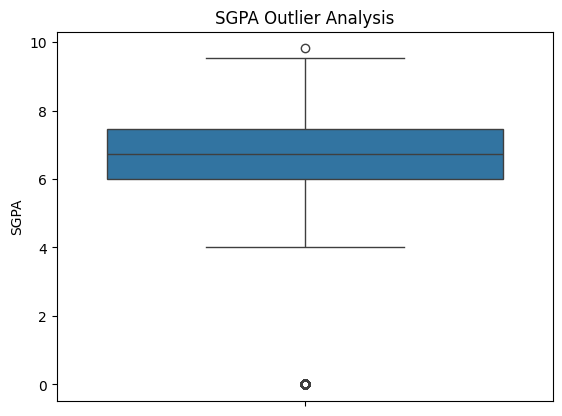

In [13]:
sns.boxplot(y=df['SGPA'])
plt.title("SGPA Outlier Analysis")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21452\1218907485.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


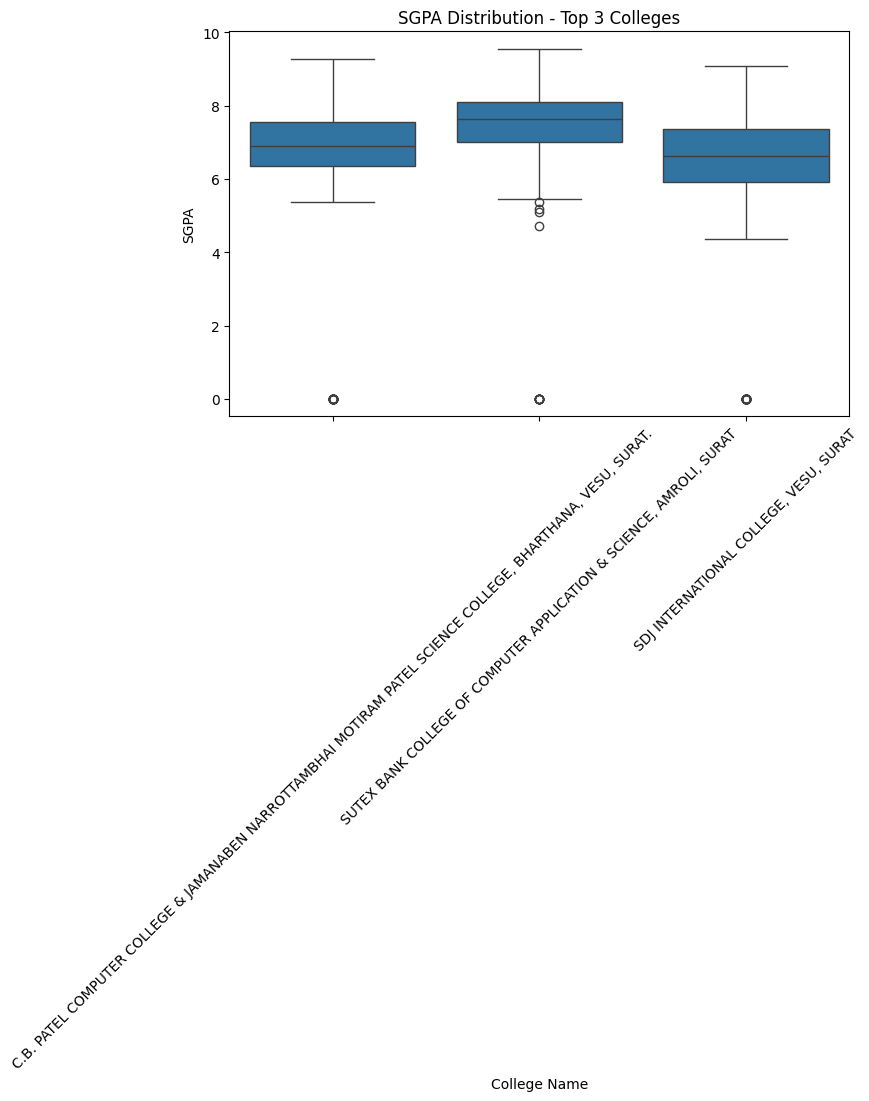

In [14]:
# Top 3 colleges by student count
top3_colleges = df['College Name'].value_counts().head(3).index

filtered_df = df[df['College Name'].isin(top3_colleges)]

plt.figure(figsize=(8,5))
sns.boxplot(x='College Name', y='SGPA', data=filtered_df)
plt.xticks(rotation=45)
plt.title("SGPA Distribution - Top 3 Colleges")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21452\2209757820.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


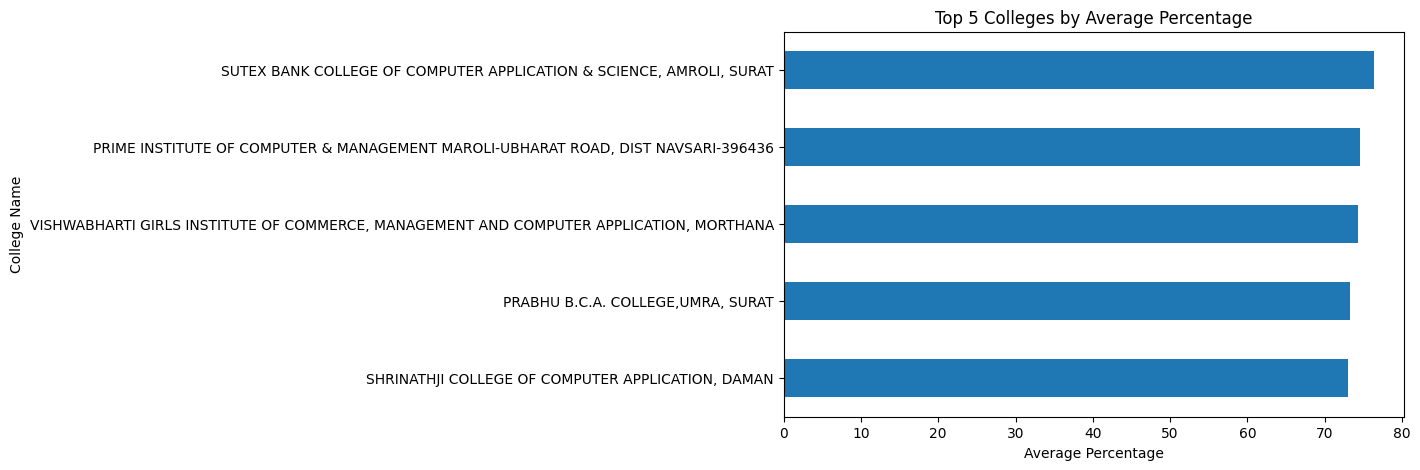

In [15]:
college_avg = df.groupby('College Name')['Percentage'].mean().sort_values(ascending=False)

top5 = college_avg.head(5)

plt.figure(figsize=(8,5))
top5.sort_values().plot(kind='barh')
plt.title("Top 5 Colleges by Average Percentage")
plt.xlabel("Average Percentage")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21452\2815227239.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


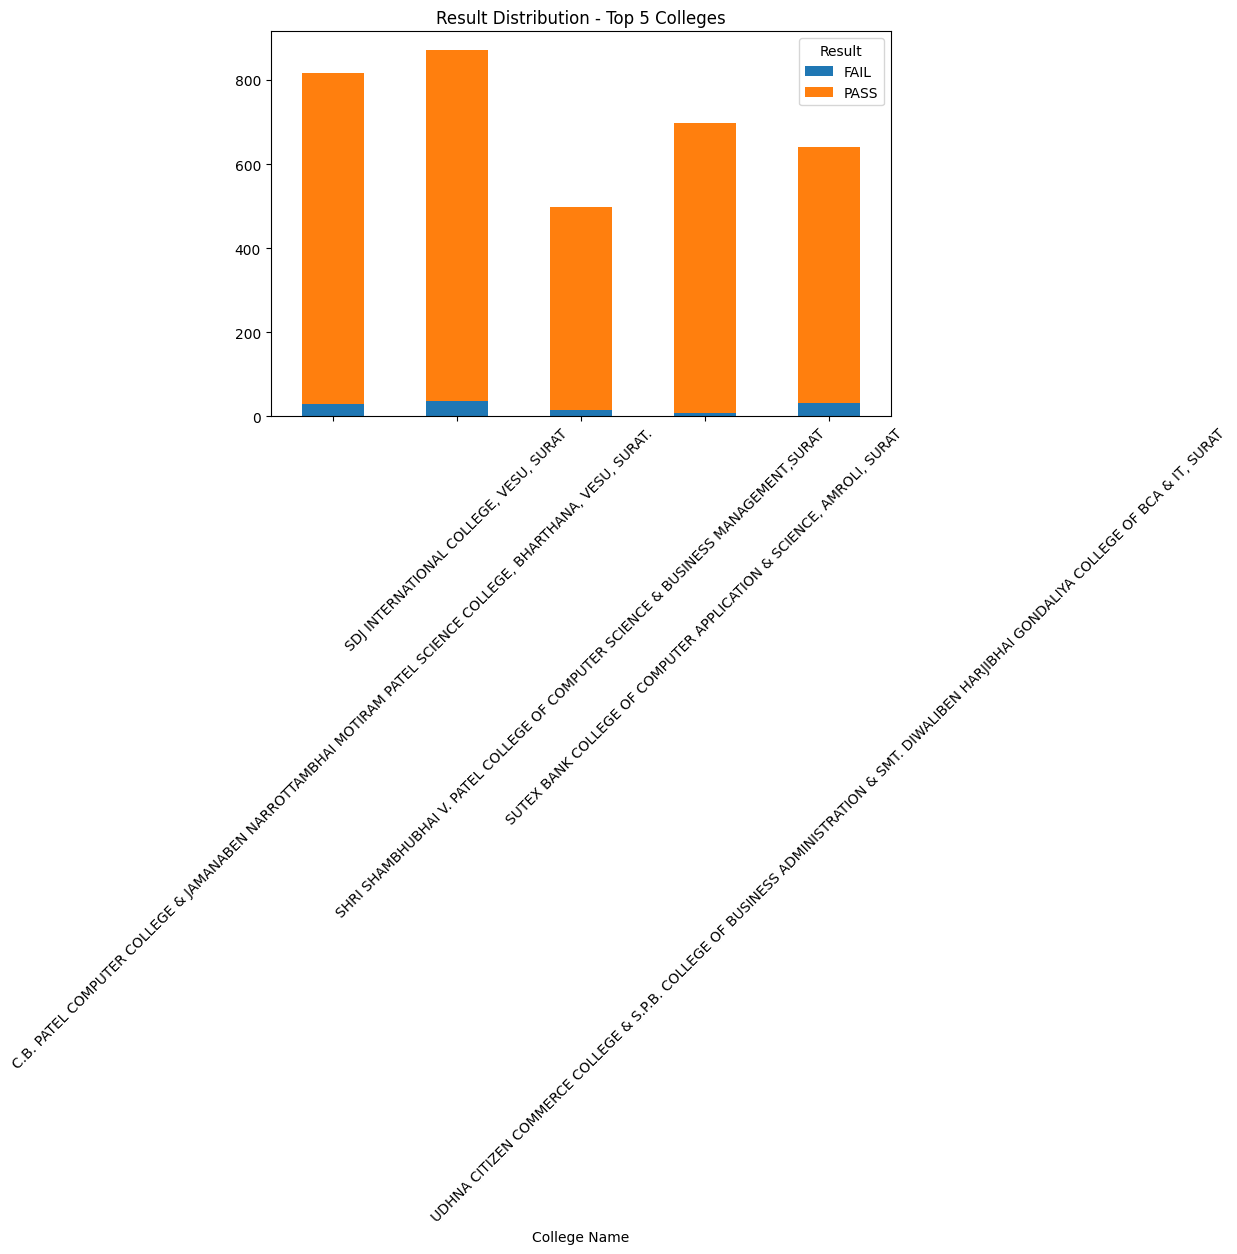

In [16]:
top5_colleges = df['College Name'].value_counts().head(5).index
filtered_df = df[df['College Name'].isin(top5_colleges)]

college_result = pd.crosstab(filtered_df['College Name'], filtered_df['Result'])

college_result.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Result Distribution - Top 5 Colleges")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

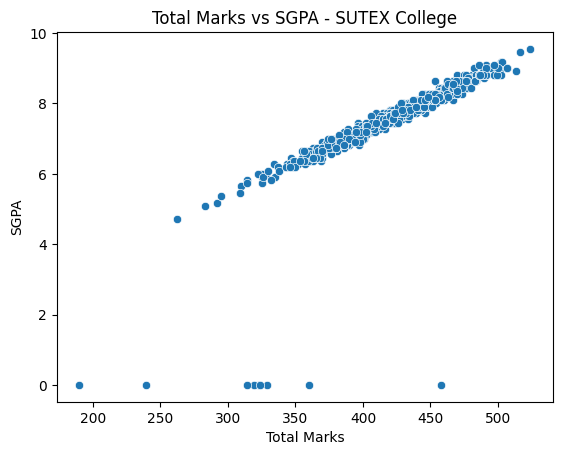

In [17]:
college_name = "SUTEX BANK COLLEGE OF COMPUTER APPLICATION & SCIENCE, AMROLI, SURAT"

college_df = df[df['College Name'] == college_name]

sns.scatterplot(x=college_df['Total Marks'], y=college_df['SGPA'])
plt.title("Total Marks vs SGPA - SUTEX College")
plt.show()

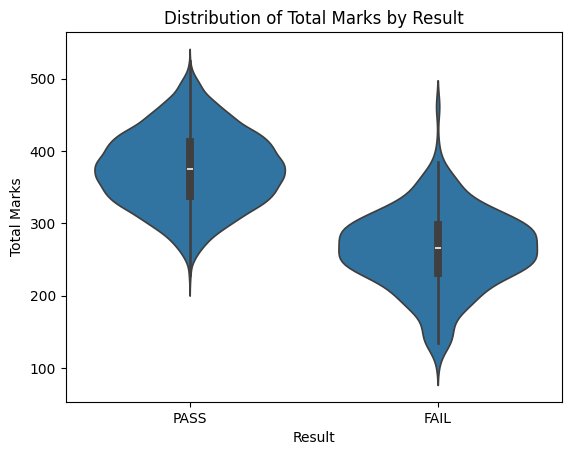

In [18]:
sns.violinplot(x='Result', y='Total Marks', data=df)
plt.title("Distribution of Total Marks by Result")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21452\2209757820.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


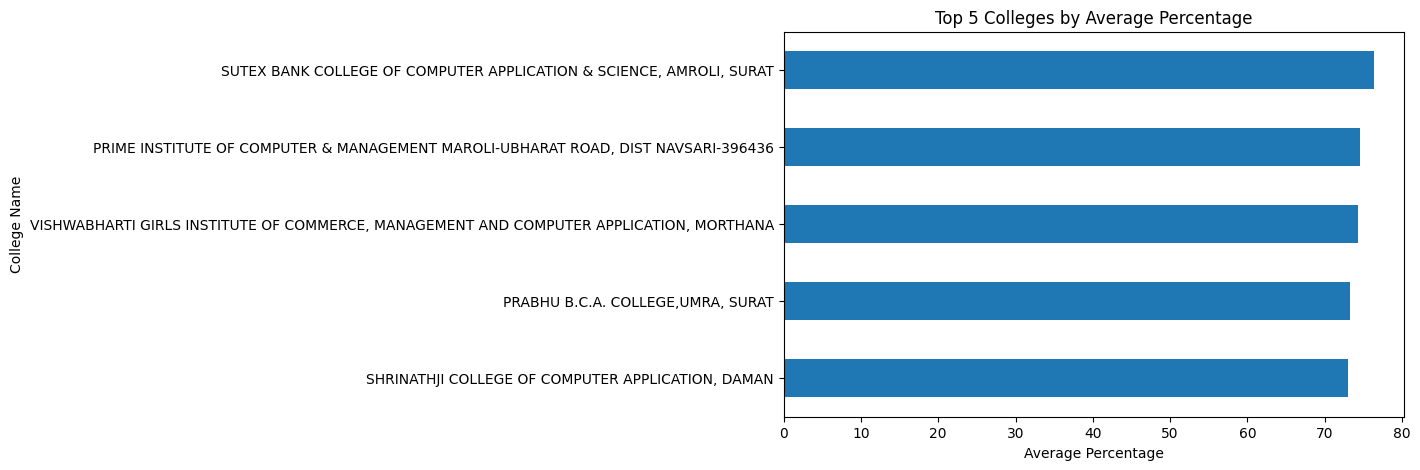

In [19]:
college_avg = df.groupby('College Name')['Percentage'].mean().sort_values(ascending=False)

top5 = college_avg.head(5)

plt.figure(figsize=(8,5))
top5.sort_values().plot(kind='barh')
plt.title("Top 5 Colleges by Average Percentage")
plt.xlabel("Average Percentage")
plt.tight_layout()
plt.show()

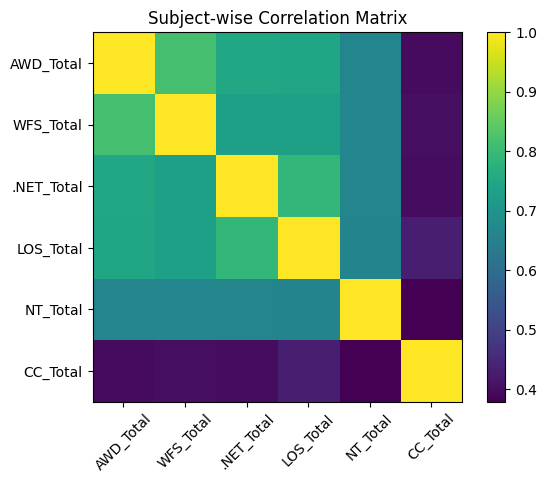

In [20]:
subject_cols = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']

corr_matrix = df[subject_cols].corr()

plt.figure()
plt.imshow(corr_matrix)
plt.xticks(range(len(subject_cols)), subject_cols, rotation=45)
plt.yticks(range(len(subject_cols)), subject_cols)
plt.title("Subject-wise Correlation Matrix")
plt.colorbar()
plt.show()

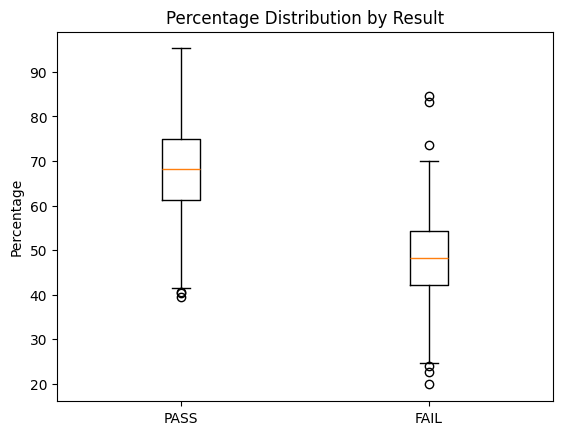

In [22]:
pass_percent = df[df['Result'] == 'PASS']['Percentage']
fail_percent = df[df['Result'] != 'PASS']['Percentage']

plt.boxplot([pass_percent, fail_percent], labels=['PASS', 'FAIL'])
plt.title("Percentage Distribution by Result")
plt.ylabel("Percentage")
plt.show()

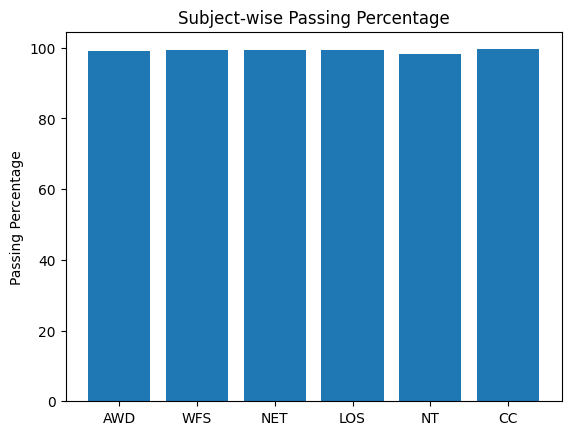

In [25]:
Passing_percentage = {
    'AWD': (df['AWD_Total'] > 33).mean() * 100,
    'WFS': (df['WFS_Total'] > 33).mean() * 100,
    'NET': (df['.NET_Total'] > 33).mean() * 100,
    'LOS': (df['LOS_Total'] > 33).mean() * 100,
    'NT': (df['NT_Total'] > 33).mean() * 100,
    'CC': (df['CC_Total'] > 18).mean() * 100
}

plt.figure()
plt.bar(Passing_percentage.keys(), Passing_percentage.values())
plt.title("Subject-wise Passing Percentage")
plt.ylabel("Passing Percentage")
plt.show()

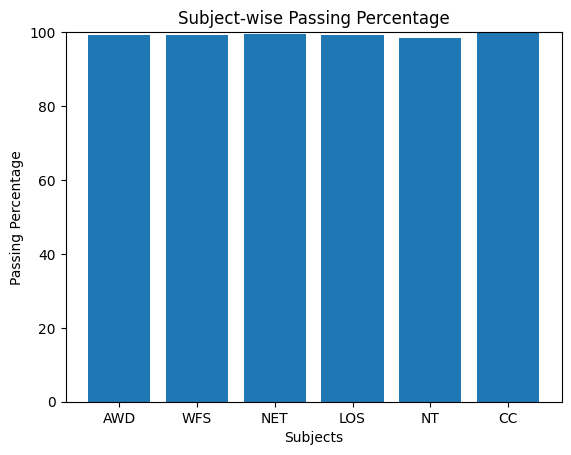

In [ ]:
import matplotlib.pyplot as plt

# Total number of students
total_students = len(df)

# Calculate passing percentage per subject
passing_percentage = {
    'AWD': (df['AWD_Total'] >= 33).sum() / total_students * 100,
    'WFS': (df['WFS_Total'] >= 33).sum() / total_students * 100,
    'NET': (df['.NET_Total'] >= 33).sum() / total_students * 100,
    'LOS': (df['LOS_Total'] >= 33).sum() / total_students * 100,
    'NT': (df['NT_Total'] >= 33).sum() / total_students * 100,
    'CC': (df['CC_Total'] >= 18).sum() / total_students * 100   # CC passing criteria
}

# Create Bar Chart
plt.figure()
plt.bar(passing_percentage.keys(), passing_percentage.values())

plt.title("Subject-wise Passing Percentage")
plt.xlabel("Subjects")
plt.ylabel("Passing Percentage")

plt.ylim(0, 100) 
plt.show()

## Multivariate

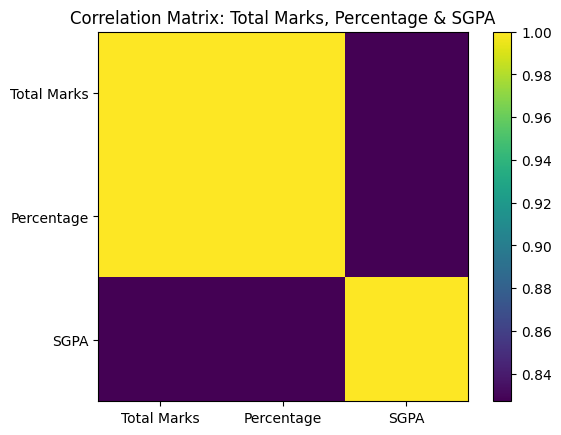

In [27]:
import matplotlib.pyplot as plt

key_cols = ['Total Marks', 'Percentage', 'SGPA']

corr_matrix = df[key_cols].corr()

plt.figure()
plt.imshow(corr_matrix)
plt.xticks(range(len(key_cols)), key_cols)
plt.yticks(range(len(key_cols)), key_cols)
plt.title("Correlation Matrix: Total Marks, Percentage & SGPA")
plt.colorbar()
plt.show()

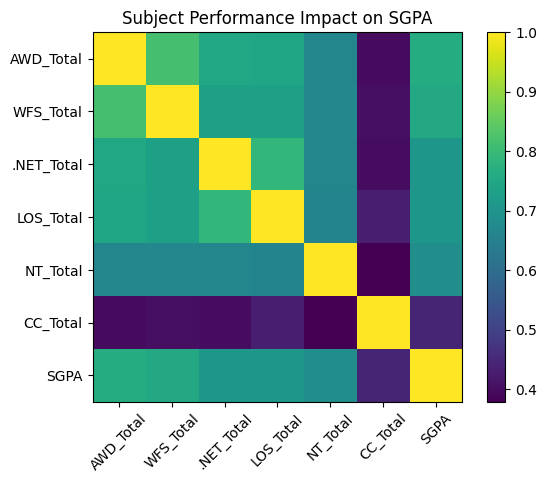

In [28]:
subject_cols = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']

combined_corr = df[subject_cols + ['SGPA']].corr()

plt.figure()
plt.imshow(combined_corr)
plt.xticks(range(len(subject_cols)+1), subject_cols + ['SGPA'], rotation=45)
plt.yticks(range(len(subject_cols)+1), subject_cols + ['SGPA'])
plt.title("Subject Performance Impact on SGPA")
plt.colorbar()
plt.show()

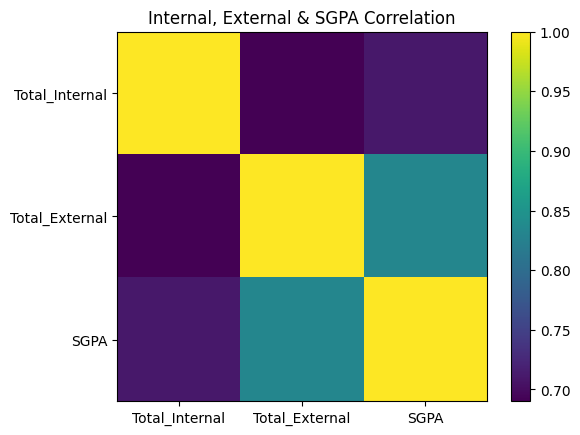

In [29]:
df['Total_Internal'] = df[['AWD_Int_Total','WFS_Int_Total','.NET_Int_Total',
                           'LOS_Int_Total','NT_Int_Total','CC_Int_Total']].sum(axis=1)

df['Total_External'] = df[['AWD_Ext_Total','WFS_Ext_Total','.NET_Ext_Total',
                           'LOS_Ext_Total','NT_Ext_Total','CC_Ext_Total']].sum(axis=1)

multi_cols = ['Total_Internal','Total_External','SGPA']

multi_corr = df[multi_cols].corr()

plt.figure()
plt.imshow(multi_corr)
plt.xticks(range(len(multi_cols)), multi_cols)
plt.yticks(range(len(multi_cols)), multi_cols)
plt.title("Internal, External & SGPA Correlation")
plt.colorbar()
plt.show()

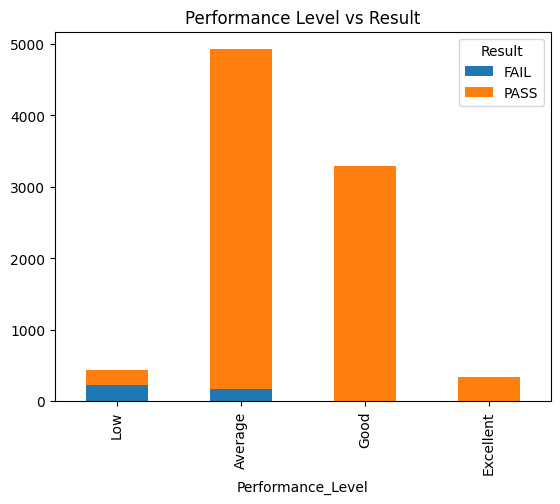

In [30]:
df['Performance_Level'] = pd.cut(
    df['Percentage'],
    bins=[0,50,70,85,100],
    labels=['Low','Average','Good','Excellent']
)

performance_summary = pd.crosstab(df['Performance_Level'], df['Result'])

performance_summary.plot(kind='bar', stacked=True)
plt.title("Performance Level vs Result")
plt.show()

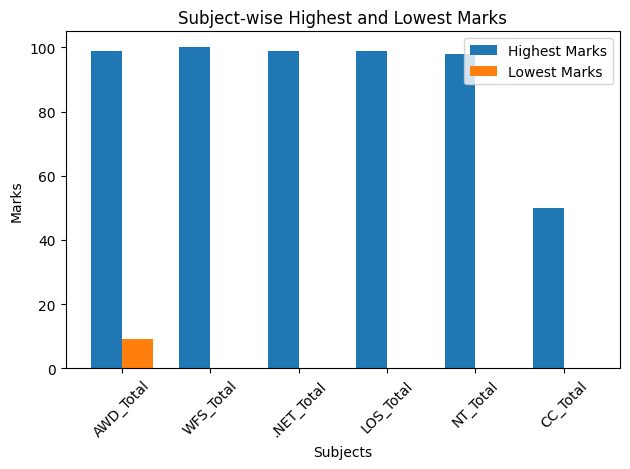

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Subject columns
subject_cols = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']

# Calculate highest and lowest marks
highest_marks = df[subject_cols].max()
lowest_marks = df[subject_cols].min()

# X-axis positions
x = np.arange(len(subject_cols))
width = 0.35

# Create plot
plt.figure()

plt.bar(x - width/2, highest_marks, width, label='Highest Marks')
plt.bar(x + width/2, lowest_marks, width, label='Lowest Marks')

plt.xticks(x, subject_cols, rotation=45)
plt.title("Subject-wise Highest and Lowest Marks")
plt.xlabel("Subjects")
plt.ylabel("Marks")
plt.legend()

plt.tight_layout()
plt.show()

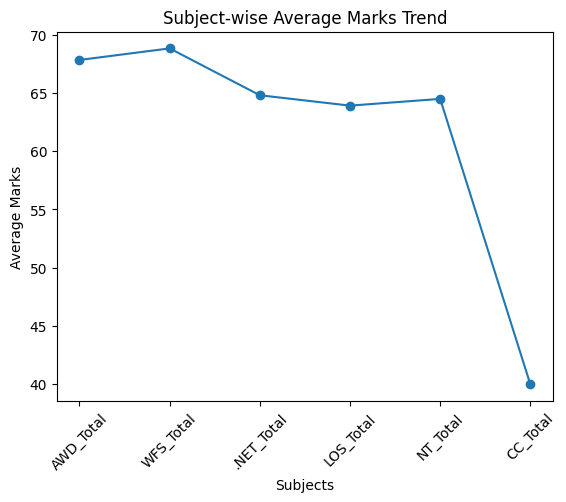

In [34]:
import matplotlib.pyplot as plt

subject_cols = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']

subject_avg = df[subject_cols].mean()

plt.figure()
plt.plot(subject_cols, subject_avg, marker='o')
plt.title("Subject-wise Average Marks Trend")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.show()

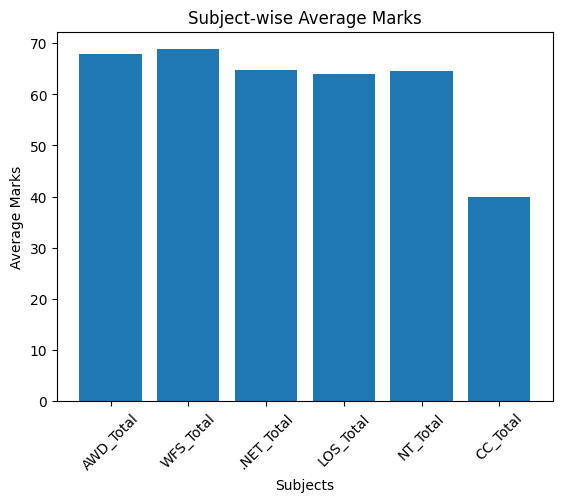

In [35]:
plt.figure()
plt.bar(subject_cols, subject_avg)
plt.title("Subject-wise Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.show()

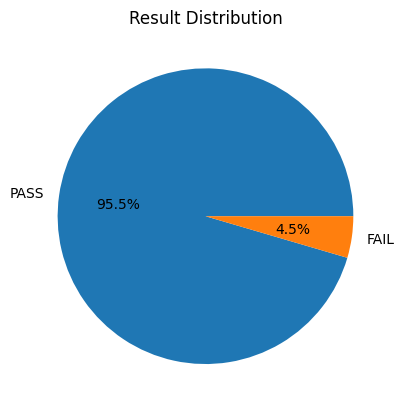

In [37]:
result_counts = df['Result'].value_counts()

plt.figure()
plt.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%')
plt.title("Result Distribution")
plt.show()

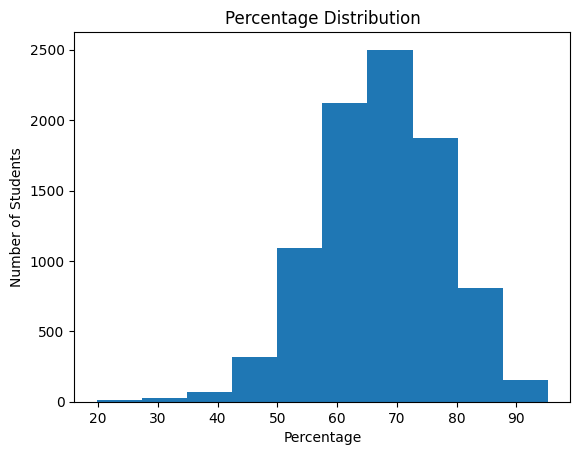

In [36]:
plt.figure()
plt.hist(df['Percentage'], bins=10)
plt.title("Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.show()

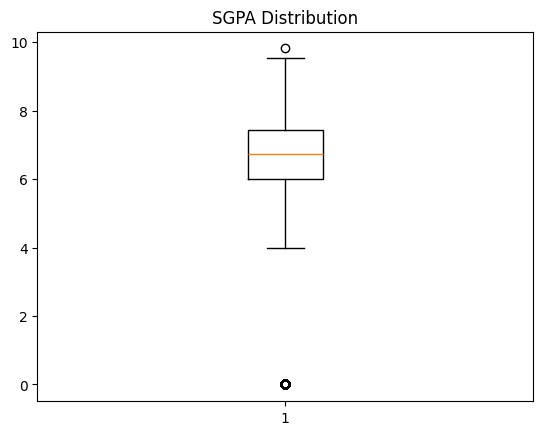

In [38]:
plt.figure()
plt.boxplot(df['SGPA'])
plt.title("SGPA Distribution")
plt.show()

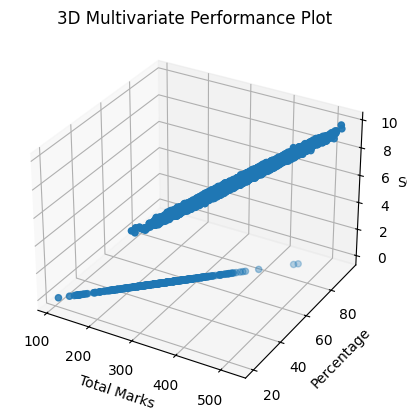

In [39]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Total Marks'],
    df['Percentage'],
    df['SGPA']
)

ax.set_xlabel("Total Marks")
ax.set_ylabel("Percentage")
ax.set_zlabel("SGPA")

plt.title("3D Multivariate Performance Plot")

plt.show()

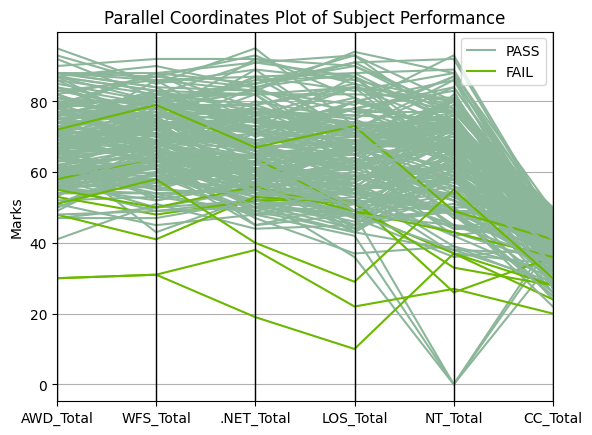

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

subject_cols = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total','Result']

sample_df = df[subject_cols].sample(200, random_state=1)  # sample to avoid clutter

plt.figure()
parallel_coordinates(sample_df, 'Result')
plt.title("Parallel Coordinates Plot of Subject Performance")
plt.ylabel("Marks")
plt.show()

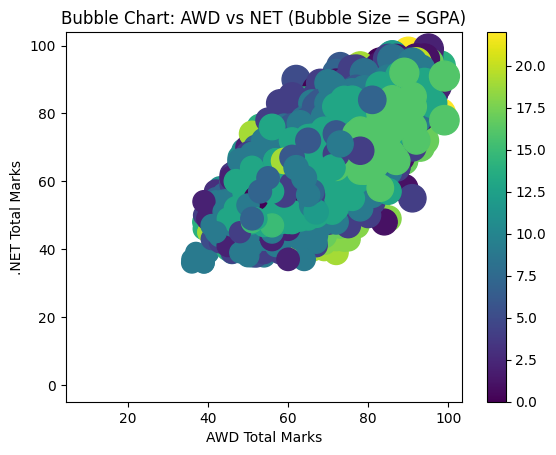

In [3]:
plt.figure()

scatter = plt.scatter(
    df['AWD_Total'],
    df['.NET_Total'],
    s=df['SGPA']*50,
    c=df['Course_Name'].astype('category').cat.codes
)

plt.title("Bubble Chart: AWD vs NET (Bubble Size = SGPA)")
plt.xlabel("AWD Total Marks")
plt.ylabel(".NET Total Marks")
plt.colorbar(scatter)
plt.show()

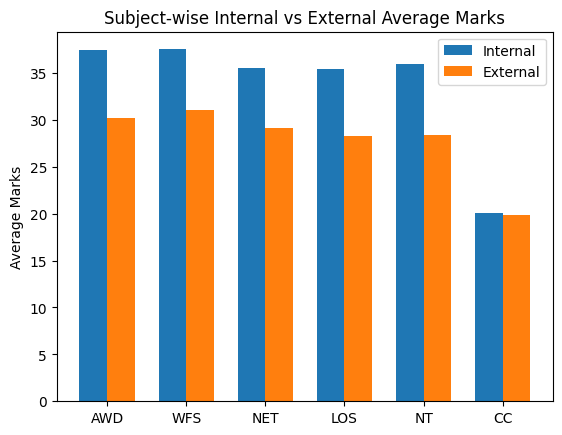

In [4]:
import numpy as np

subjects = ['AWD','WFS','NET','LOS','NT','CC']

internal_avg = [
df['AWD_Int_Total'].mean(),
df['WFS_Int_Total'].mean(),
df['.NET_Int_Total'].mean(),
df['LOS_Int_Total'].mean(),
df['NT_Int_Total'].mean(),
df['CC_Int_Total'].mean()
]

external_avg = [
df['AWD_Ext_Total'].mean(),
df['WFS_Ext_Total'].mean(),
df['.NET_Ext_Total'].mean(),
df['LOS_Ext_Total'].mean(),
df['NT_Ext_Total'].mean(),
df['CC_Ext_Total'].mean()
]

x = np.arange(len(subjects))
width = 0.35

plt.figure()

plt.bar(x-width/2, internal_avg, width, label='Internal')
plt.bar(x+width/2, external_avg, width, label='External')

plt.xticks(x, subjects)
plt.title("Subject-wise Internal vs External Average Marks")
plt.ylabel("Average Marks")
plt.legend()

plt.show()

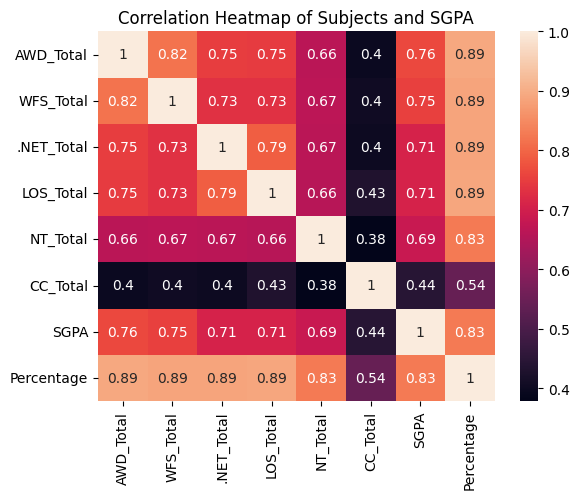

In [5]:
import seaborn as sns

cols = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total','SGPA','Percentage']

plt.figure()
sns.heatmap(df[cols].corr(), annot=True)

plt.title("Correlation Heatmap of Subjects and SGPA")
plt.show()

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  self._figure.tight_layout(*args, **kwargs)


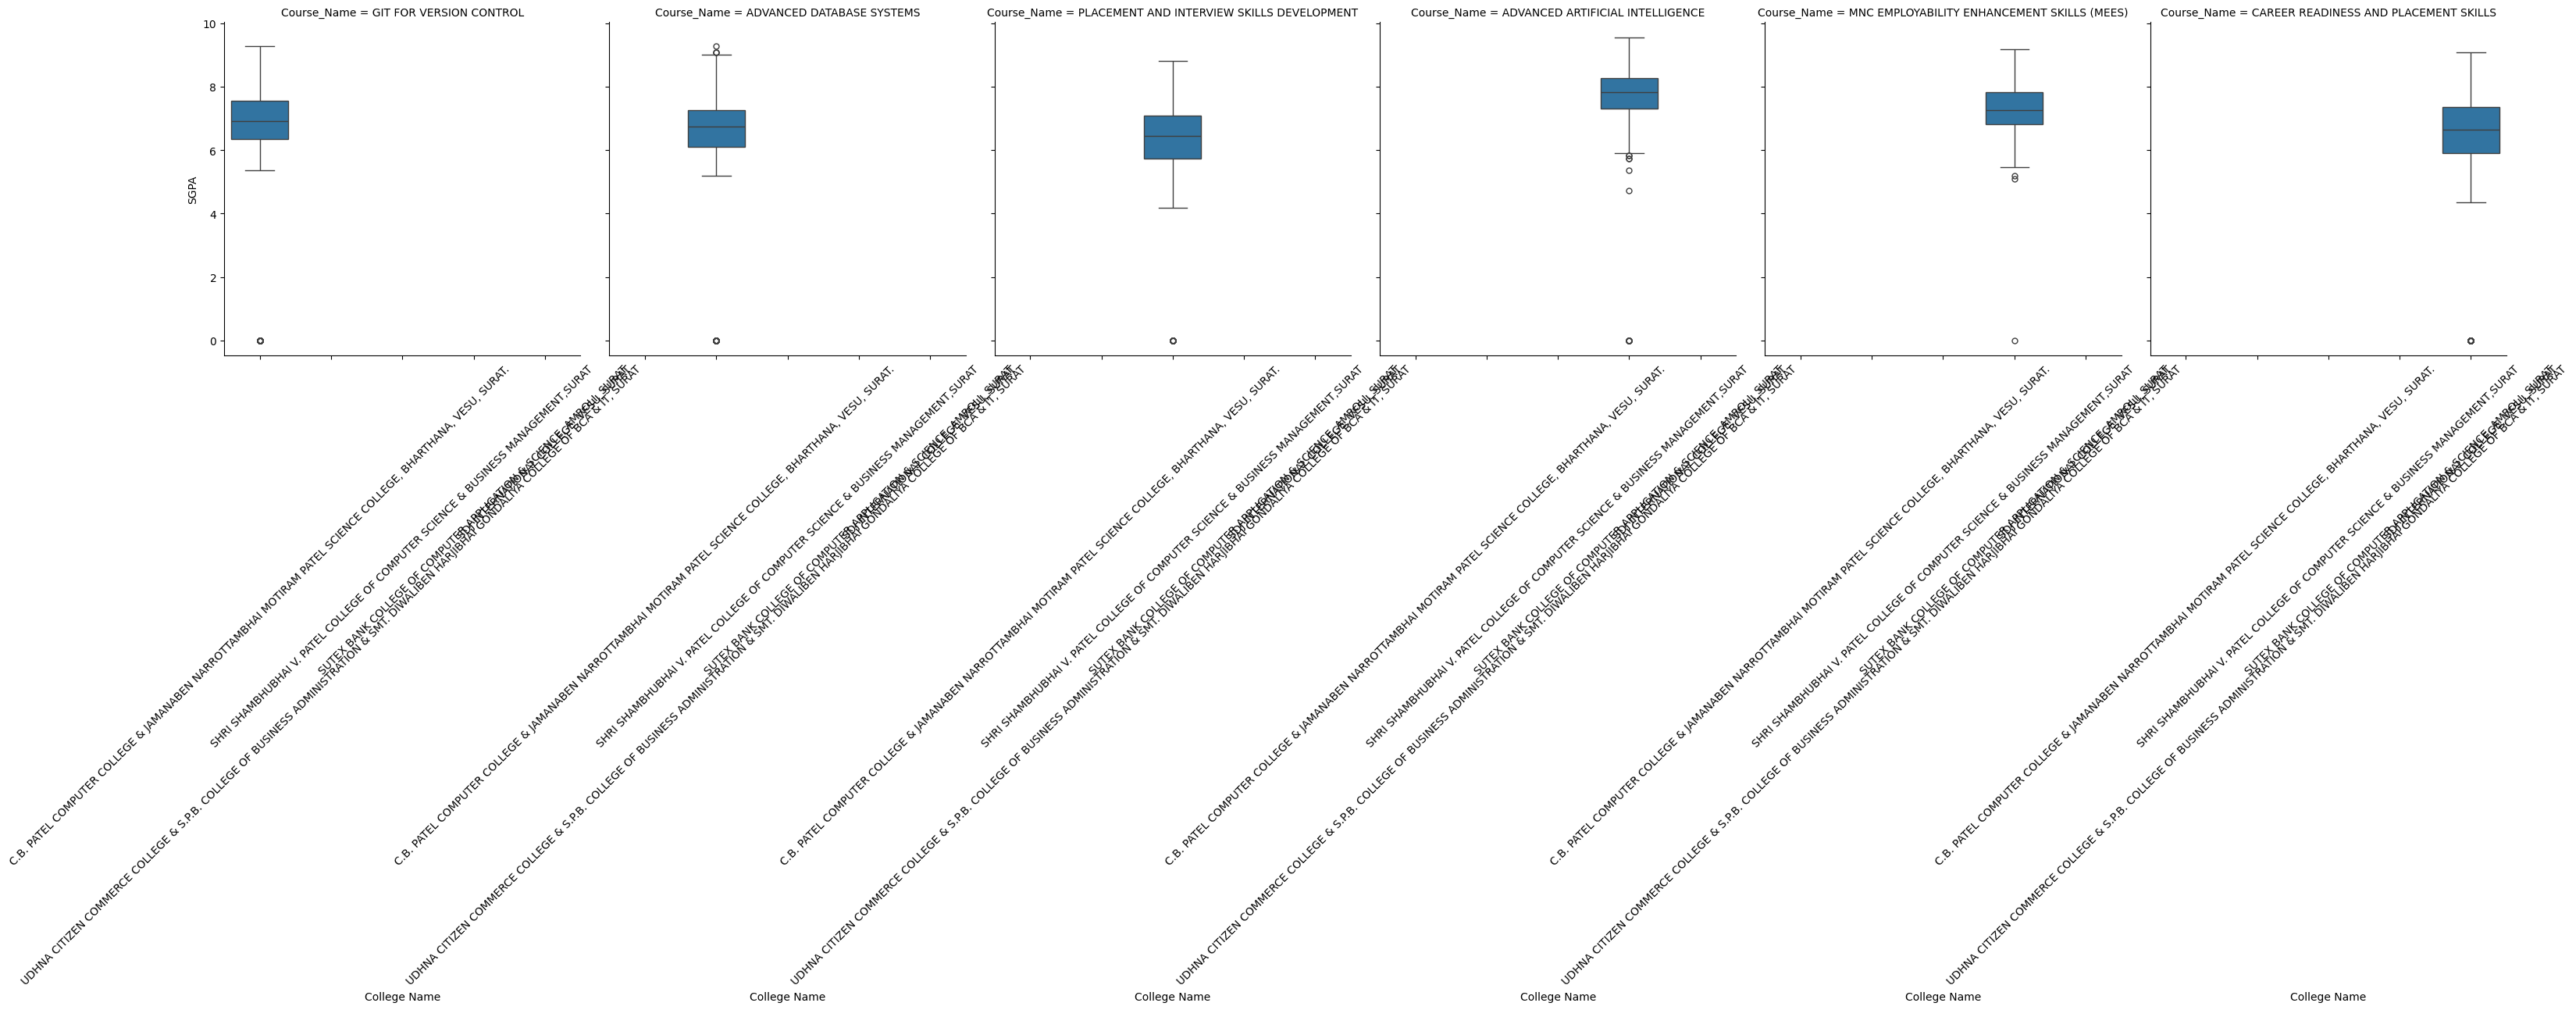

In [6]:
import seaborn as sns

top_colleges = df['College Name'].value_counts().head(5).index
subset = df[df['College Name'].isin(top_colleges)]

g = sns.catplot(
    data=subset,
    x='College Name',
    y='SGPA',
    col='Course_Name',
    kind='box'
)

g.set_xticklabels(rotation=45)
plt.show()

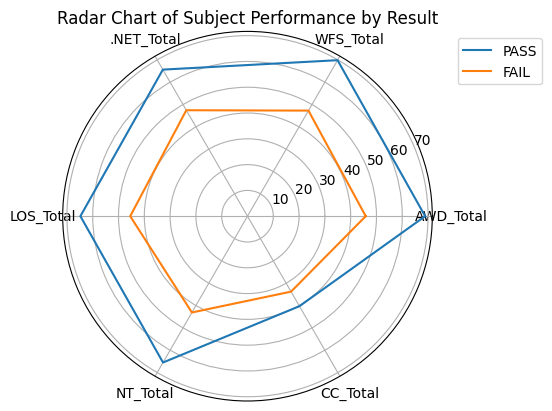

In [14]:
import numpy as np
import matplotlib.pyplot as plt

subjects = ['AWD_Total','WFS_Total','.NET_Total','LOS_Total','NT_Total','CC_Total']

pass_avg = df[df['Result']=='PASS'][subjects].mean().values
fail_avg = df[df['Result']!='PASS'][subjects].mean().values

angles = np.linspace(0,2*np.pi,len(subjects),endpoint=False)

pass_avg = np.concatenate((pass_avg,[pass_avg[0]]))
fail_avg = np.concatenate((fail_avg,[fail_avg[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure()
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, pass_avg, label='PASS')
ax.plot(angles, fail_avg, label='FAIL')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(subjects)

plt.title("Radar Chart of Subject Performance by Result")

# Move legend outside
plt.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.show()

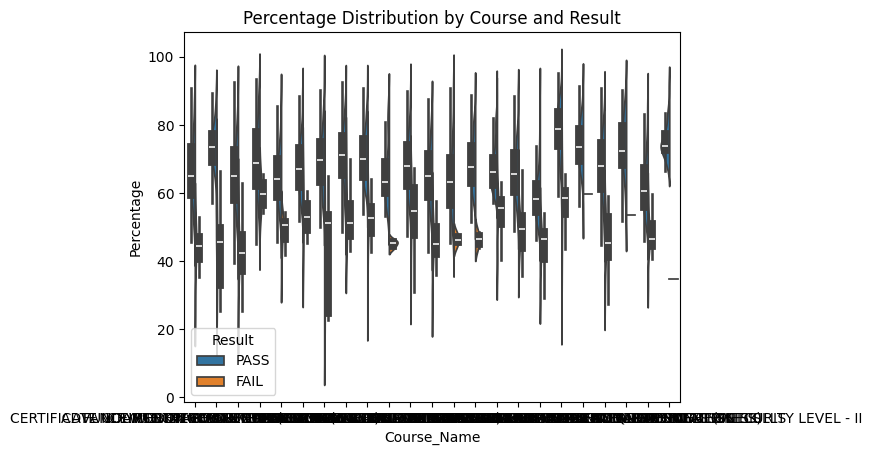

In [8]:
import seaborn as sns

plt.figure()

sns.violinplot(
    x='Course_Name',
    y='Percentage',
    hue='Result',
    data=df,
    split=True
)

plt.title("Percentage Distribution by Course and Result")
plt.show()

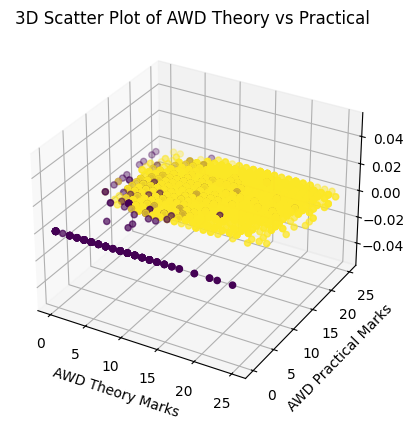

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['AWD_Ext_Th'],
    df['AWD_Ext_Pr'],
    c=df['Result'].astype('category').cat.codes
)

ax.set_xlabel("AWD Theory Marks")
ax.set_ylabel("AWD Practical Marks")


plt.title("3D Scatter Plot of AWD Theory vs Practical ")

plt.show()

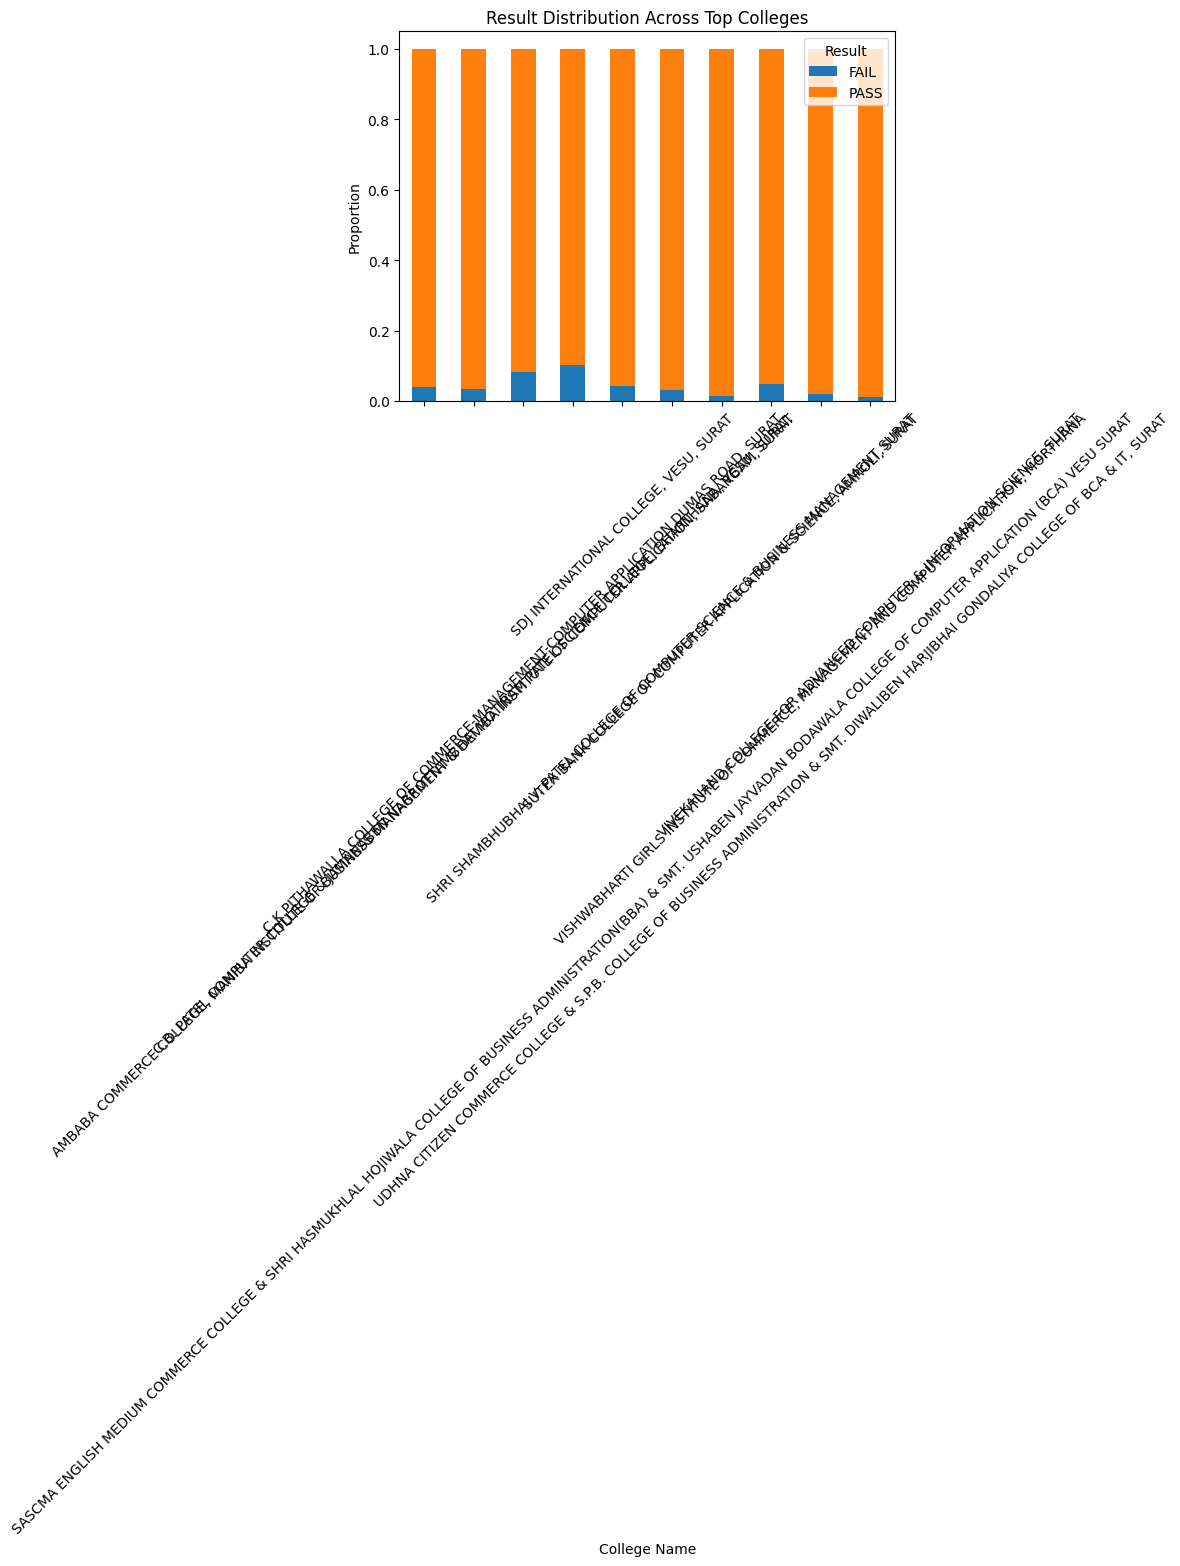

In [12]:
top10 = df['College Name'].value_counts().head(10).index
subset = df[df['College Name'].isin(top10)]

ct = pd.crosstab(subset['College Name'], subset['Result'], normalize='index')

ct.plot(kind='bar', stacked=True)

plt.title("Result Distribution Across Top Colleges")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

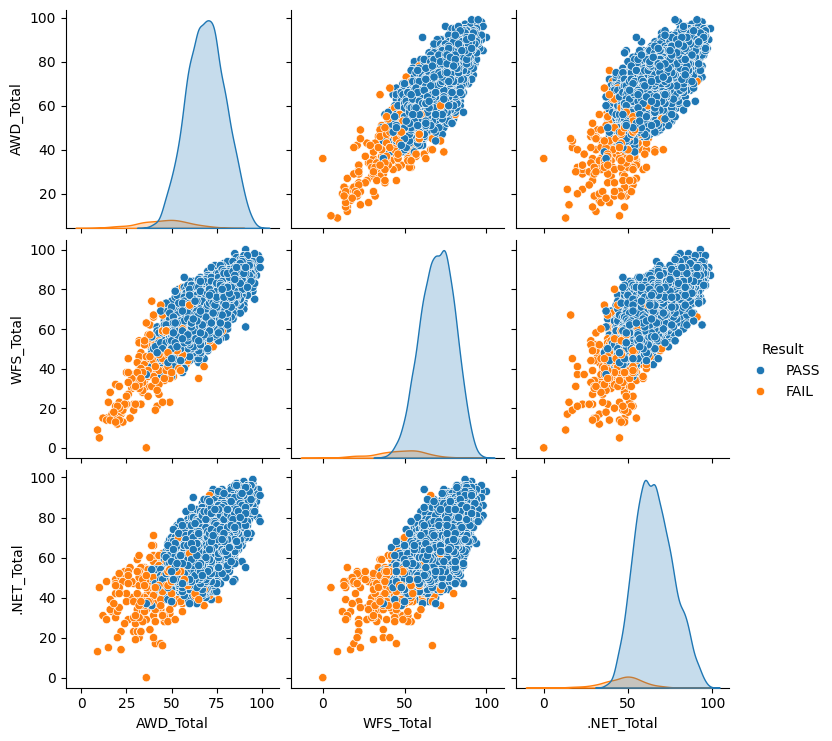

In [13]:
import seaborn as sns

sns.pairplot(
    df[['AWD_Total','WFS_Total','.NET_Total','Result']],
    hue='Result'
)

plt.show()